In [51]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from datetime import datetime
import random

# ----------- CONFIG -----------
FOLDER_PATH = "/Users/ardacanseradali/Documents/Thesis_master/HF-Models-P7" # <- Update this
# FOLDER_PATH = "/Users/ardacanseradali/Documents/Thesis_master/HF-Models-P9"  # <- Update this

# ------------------------------
colors = ["#0F67B4", "#1768E1", "#23A5C9", "#04A57F", "#057D4F"]

# Get all .json files in the directory
all_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".json")]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
# Sample 1% of files (at least 1 file)
SAMPLE = 1 # 0.01
sample_size = max(1, int(len(all_files) * SAMPLE))
sampled_files = random.sample(all_files, sample_size)


def has_description(data):
    description = data.get("description", None)
    return len(set(description.split()))

likes_list = []
p_tags_set = set()
pipeline_tags = {}
modified_list = []
file_list = []
description_list = []


# ----------- DATA EXTRACTION -----------
for filename in tqdm(sampled_files):
    if filename.endswith(".json"):
        file_path = os.path.join(FOLDER_PATH, filename)
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                
                # likes
                likes = data.get("likes", None)
                likes_list.append(likes)
                # file

                files = data.get("file_count", None)
                file_list.append(files)

                #description
                descriptions = has_description(data)
                description_list.append(descriptions)
                # pipeline_tag
                p_tag = data.get("pipeline_tag") or "none"
                if p_tag not in p_tags_set:
                    pipeline_tags[p_tag] = 1
                    p_tags_set.add(p_tag)
                else: 
                    pipeline_tags[p_tag] += 1

                # last_modified
                l_modified = data.get("lastModified", None)
                try:
                    last_modified_dt = datetime.fromisoformat(l_modified.replace("Z", "+00:00"))
                    modified_list.append(last_modified_dt.year)
                except:
                    pass

        except Exception as e:
            print(f"❌ Error reading {filename}: {e}")

100%|██████████| 48384/48384 [00:10<00:00, 4463.25it/s]


# SON HALI F_PLOTS_MODELS

In [ ]:
print(pipeline_tags)

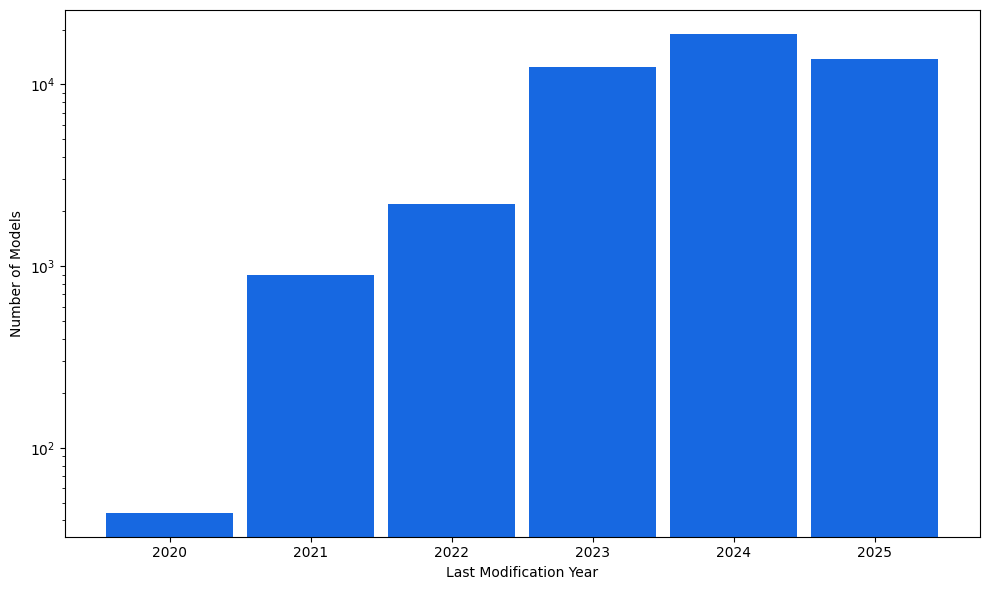

In [27]:
import matplotlib.pyplot as plt
from collections import Counter

# Example: modified_list contains integers
# e.g., modified_list = [2023, 2024, 2025, 2025, 2023, 2024]

# Count occurrences
counts = Counter(modified_list)

# Get unique values sorted
unique_values = sorted(counts.keys())
frequencies = [counts[val] for val in unique_values]

plt.figure(figsize=(10, 6))

# Use range(len(unique_values)) as x positions to get uniform spacing
x_pos = range(len(unique_values))
bar_width = 0.9
plt.bar(x_pos, frequencies, color= colors[1], width = bar_width)

plt.xticks(x_pos, unique_values)  # label ticks with actual values
plt.xlabel("Last Modification Year")
plt.ylabel("Number of Models")
plt.yscale("log")
plt.tight_layout()
plt.show()


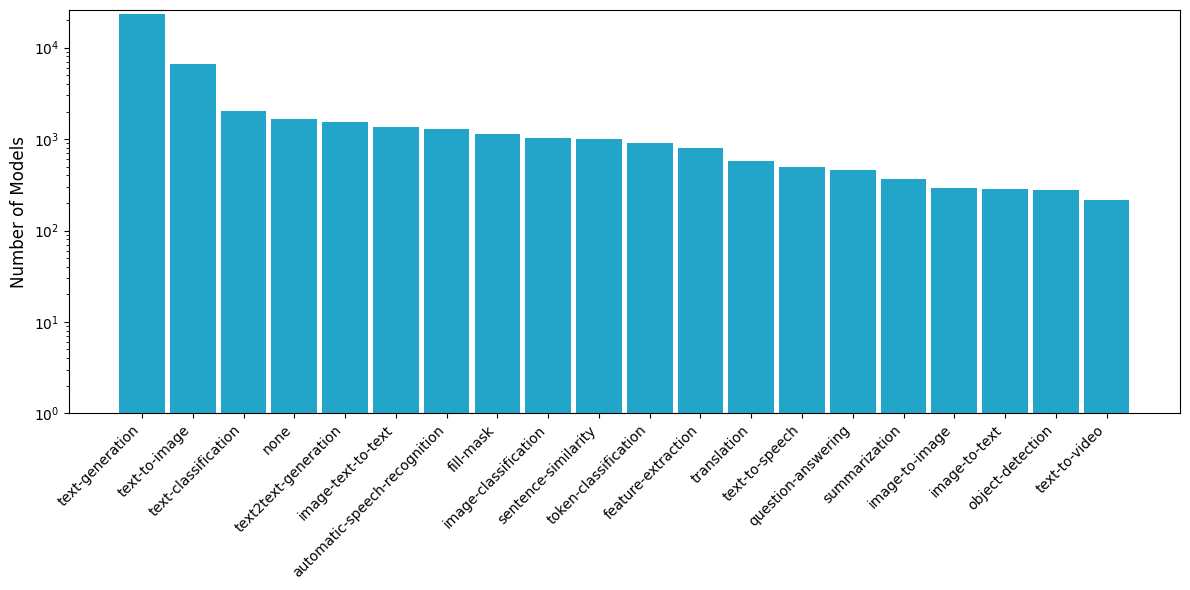

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Convert to Series and sort descending
pipeline_series = pd.Series(pipeline_tags).sort_values(ascending=False)

# Take top N
top_n = 20
top_pipelines = pipeline_series.head(top_n)

# Create figure
fig, ax = plt.subplots(figsize=(12,6))

# Plot bars
bar_width = 0.9
ax.bar(top_pipelines.index, top_pipelines.values, color= colors[2], alpha=1, width=bar_width)

# Logarithmic y-axis
ax.set_yscale("log")
ax.set_ylim(1, top_pipelines.values.max() * 1.1)  # 1 is 10^0
ax.set_ylabel("Number of Models", fontsize=12)
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())


# # Optional: add value labels
# for i, value in enumerate(top_pipelines.values):
#     ax.text(i, value, str(value), ha='center', va='bottom', fontsize=10)

# Labels and style
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


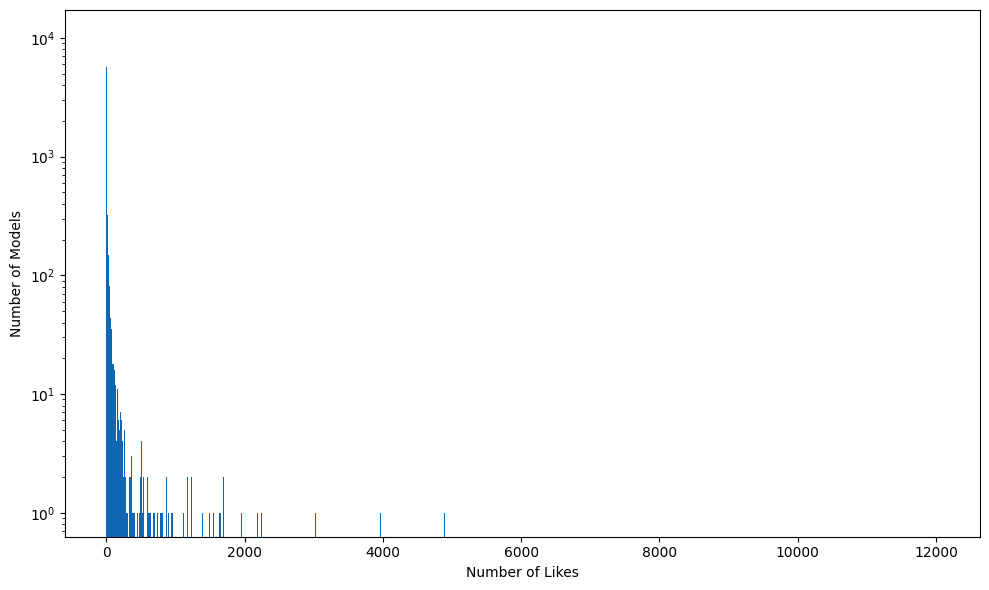

There are 0 models with zero likes.


In [29]:

# Plot histogram
plt.figure(figsize=(10, 6))
bins = range(0, max(likes_list) + 2)  # e.g., 0 to max+1
counts, bin_edges, patches = plt.hist(likes_list, bins=bins, color= colors[0])

# Annotate the bar at 0
zero_index = list(bin_edges).index(1) - 1  # bin_edges[0] is for 0
zero_count = int(counts[zero_index])
if zero_count > 0:
    plt.text(
        bin_edges[zero_index] + 10,  # x
        zero_count + 1,              # y (just above the bar)
        f"{zero_count} Zeros",       # text
        fontsize=9,
        color='dimgray'
    )

plt.xlabel("Number of Likes")
plt.ylabel("Number of Models")
# plt.grid(True)
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"There are {zero_count} models with zero likes.")


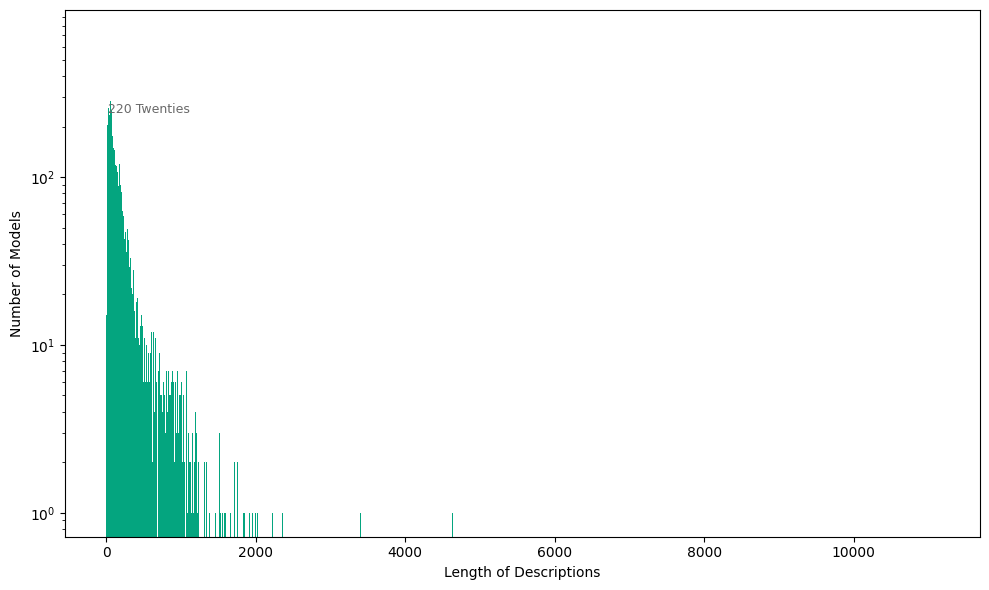

There are 220 models with zero likes.
[0. 0. 0. ... 0. 0. 1.]


In [30]:
# Plot histogram
plt.figure(figsize=(10, 6))
bins = range(0, max(description_list) + 2)  # e.g., 0 to max+1
counts, bin_edges, patches = plt.hist(description_list, bins=bins, color= colors[3])

#Annotate the bar at 0
zero_index = list(bin_edges).index(20)  # -1 var mi yok mu ???
zero_count = int(counts[zero_index])
if zero_count > 0:
    plt.text(
    bin_edges[zero_index] + 0.5,  # center of the bin
    zero_count * 1.1,             # slightly above the bar (works on log scale)
    f"{zero_count} Twenties",
    fontsize=9,
    color='dimgray'
)

plt.xlabel("Length of Descriptions")
plt.ylabel("Number of Models")
# plt.grid(True)
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"There are {zero_count} models with zero likes.")
print(counts)

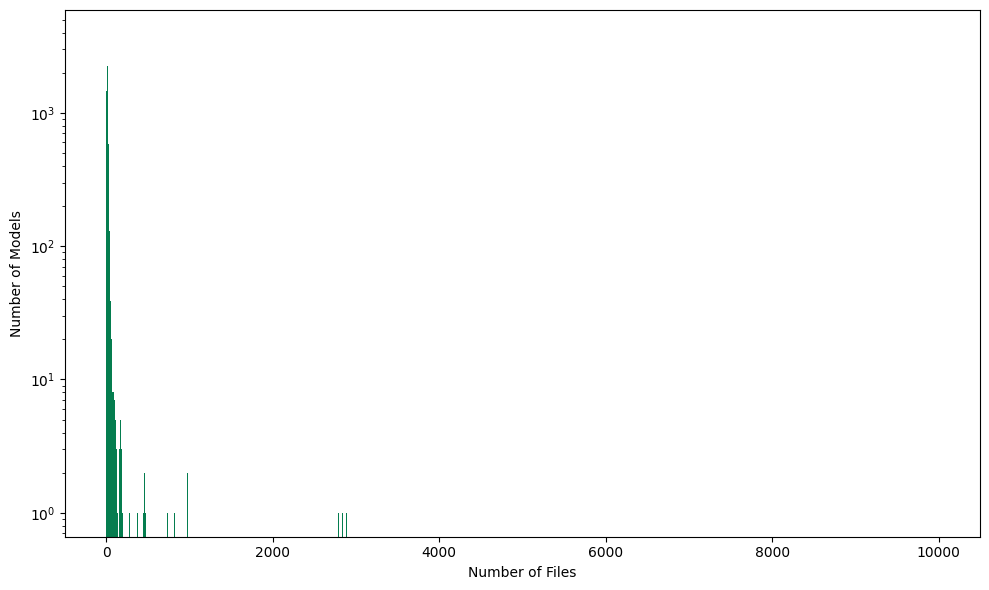

There are 0 models with zero likes.


In [31]:

# Plot histogram
plt.figure(figsize=(10, 6))
bins = range(0, max(file_list) + 2)  # e.g., 0 to max+1
counts, bin_edges, patches = plt.hist(file_list, bins=bins, color=colors[4])

# Annotate the bar at 0
zero_index = list(bin_edges).index(2) -1  # -1 var mi yok mu ???
zero_count = int(counts[zero_index])
if zero_count > 0:
    plt.text(
        bin_edges[zero_index]+0.5,
        zero_count*1.1,          # y (just above the bar)
        f"{zero_count} Ones",       # text
        fontsize=9,
        color='dimgray'
    )

plt.xlabel("Number of Files")
plt.ylabel("Number of Models")
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"There are {zero_count} models with zero likes.")

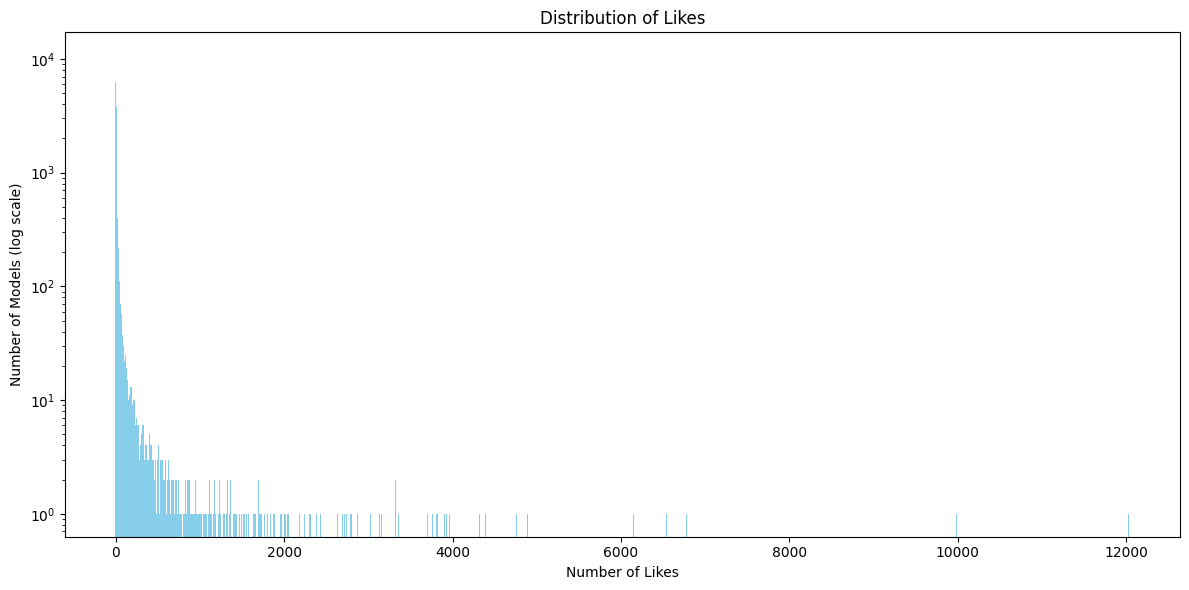

In [48]:
import matplotlib.pyplot as plt
import numpy as np

counts = np.bincount(likes_list)
x = np.arange(len(counts))

# Plot (using bar or line for performance)
plt.figure(figsize=(12, 6))
plt.bar(x, counts, width=10.0, color='skyblue', edgecolor='none')

# Log scale on Y-axis
plt.yscale('log')

# Labels and title
plt.xlabel("Number of Likes")
plt.ylabel("Number of Models (log scale)")
plt.title("Distribution of Likes")

# Annotate zero bar
zero_count = counts[0]
if zero_count > 0:
    plt.text(10, zero_count * 1.1, f"{zero_count:,} zeros", fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()


ValueError: 2 is not in list

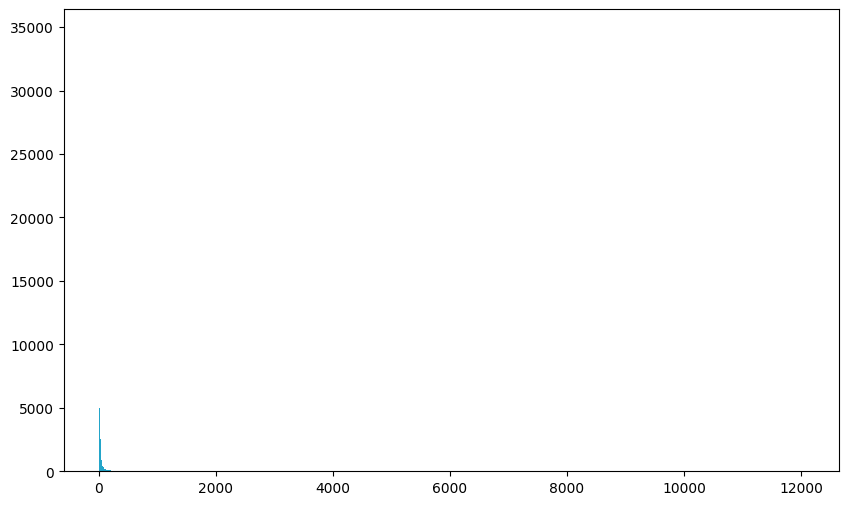

In [54]:
# Plot histogram
plt.figure(figsize=(10, 6))
bar_width = 10  # each bin will cover 5 integers
# Define bins
bins = np.arange(0, max(likes_list) + bar_width, bar_width)
counts, bin_edges, patches = plt.hist(likes_list, bins=bins, color= colors[2])

# Annotate the bar at 0
zero_index = list(bin_edges).index(2) - 1  # bin_edges[0] is for 0
zero_count = int(counts[zero_index])
if zero_count > 0:
    plt.text(
        bin_edges[zero_index] + 10,  # x
        zero_count + 1,                 # y (just above the bar)
        f"{zero_count} Zeros",       # text
        fontsize=9,
        color='dimgray'
    )

plt.xlabel("Number of Likes")
plt.ylabel("Number of Models")
# plt.grid(True)
plt.yscale("log")
plt.tight_layout()
plt.savefig("model_p1_likes.png")
plt.show()

print(f"There are {zero_count} models with zero likes.")

In [44]:
from collections import Counter



# Count occurrences
counts = Counter(file_list)

# Create a dictionary sorted by keys (numbers)
sorted_counts = dict(sorted(counts.items()))
print(len(sorted_counts))
print(sorted_counts)

380
{2: 163, 3: 1451, 4: 1677, 5: 1599, 6: 1474, 7: 1754, 8: 2818, 9: 3275, 10: 3471, 11: 3163, 12: 3903, 13: 3359, 14: 2604, 15: 2243, 16: 1768, 17: 1766, 18: 1397, 19: 883, 20: 804, 21: 715, 22: 657, 23: 632, 24: 506, 25: 691, 26: 438, 27: 581, 28: 453, 29: 274, 30: 407, 31: 199, 32: 144, 33: 105, 34: 120, 35: 114, 36: 92, 37: 104, 38: 284, 39: 130, 40: 93, 41: 90, 42: 132, 43: 98, 44: 73, 45: 79, 46: 51, 47: 58, 48: 37, 49: 81, 50: 39, 51: 39, 52: 36, 53: 32, 54: 27, 55: 20, 56: 24, 57: 30, 58: 25, 59: 32, 60: 19, 61: 19, 62: 11, 63: 20, 64: 20, 65: 18, 66: 10, 67: 20, 68: 31, 69: 30, 70: 23, 71: 25, 72: 19, 73: 16, 74: 19, 75: 8, 76: 19, 77: 12, 78: 14, 79: 16, 80: 9, 81: 4, 82: 3, 83: 9, 84: 17, 85: 6, 86: 3, 87: 8, 88: 10, 89: 4, 90: 13, 91: 5, 92: 12, 93: 4, 94: 7, 95: 13, 96: 5, 97: 3, 98: 4, 99: 7, 100: 3, 101: 3, 102: 8, 103: 8, 104: 2, 105: 2, 106: 5, 107: 3, 108: 5, 109: 4, 110: 7, 111: 5, 112: 3, 113: 3, 114: 6, 115: 5, 116: 2, 117: 8, 118: 6, 119: 7, 120: 3, 121: 5, 122: 

In [35]:
# Find the number with the maximum count
max_number = max(counts, key=counts.get)
max_count = counts[max_number]

print(f"Number with max count: {max_number} (count = {max_count})")

Number with max count: 12 (count = 3903)


In [40]:
# Count occurrences
counts = Counter(likes_list)

# Create a dictionary sorted by keys (numbers)
sorted_counts = dict(sorted(counts.items()))

print(len(sorted_counts))
print(sorted_counts)

766
{1: 6262, 2: 10768, 3: 5722, 4: 3763, 5: 2618, 6: 1967, 7: 1443, 8: 1162, 9: 966, 10: 838, 11: 699, 12: 653, 13: 546, 14: 460, 15: 453, 16: 397, 17: 349, 18: 322, 19: 266, 20: 344, 21: 307, 22: 282, 23: 259, 24: 236, 25: 249, 26: 230, 27: 215, 28: 218, 29: 180, 30: 173, 31: 154, 32: 147, 33: 135, 34: 131, 35: 156, 36: 129, 37: 132, 38: 128, 39: 119, 40: 112, 41: 91, 42: 103, 43: 91, 44: 77, 45: 90, 46: 88, 47: 81, 48: 84, 49: 67, 50: 65, 51: 75, 52: 61, 53: 60, 54: 66, 55: 60, 56: 55, 57: 70, 58: 39, 59: 50, 60: 49, 61: 44, 62: 38, 63: 51, 64: 40, 65: 49, 66: 57, 67: 41, 68: 40, 69: 33, 70: 35, 71: 37, 72: 35, 73: 25, 74: 44, 75: 44, 76: 35, 77: 35, 78: 37, 79: 32, 80: 26, 81: 31, 82: 25, 83: 20, 84: 27, 85: 31, 86: 24, 87: 20, 88: 21, 89: 30, 90: 18, 91: 23, 92: 23, 93: 19, 94: 16, 95: 24, 96: 16, 97: 14, 98: 19, 99: 17, 100: 14, 101: 20, 102: 15, 103: 20, 104: 18, 105: 15, 106: 22, 107: 15, 108: 13, 109: 16, 110: 21, 111: 14, 112: 25, 113: 6, 114: 9, 115: 21, 116: 19, 117: 12, 11

In [45]:
# Count occurrences
counts = Counter(description_list)

# Create a dictionary sorted by keys (numbers)
sorted_counts = dict(sorted(counts.items()))

print(len(sorted_counts))
print(sorted_counts)

1505
{3: 9, 4: 15, 5: 22, 6: 33, 7: 29, 8: 49, 9: 72, 10: 188, 11: 77, 12: 160, 13: 129, 14: 120, 15: 150, 16: 229, 17: 204, 18: 521, 19: 257, 20: 220, 21: 163, 22: 240, 23: 190, 24: 230, 25: 475, 26: 198, 27: 364, 28: 191, 29: 252, 30: 259, 31: 172, 32: 205, 33: 217, 34: 176, 35: 203, 36: 197, 37: 398, 38: 187, 39: 214, 40: 264, 41: 583, 42: 210, 43: 303, 44: 234, 45: 378, 46: 416, 47: 367, 48: 250, 49: 254, 50: 236, 51: 243, 52: 209, 53: 323, 54: 285, 55: 214, 56: 209, 57: 283, 58: 213, 59: 210, 60: 275, 61: 215, 62: 208, 63: 176, 64: 201, 65: 199, 66: 206, 67: 216, 68: 211, 69: 200, 70: 222, 71: 253, 72: 236, 73: 234, 74: 268, 75: 234, 76: 329, 77: 232, 78: 199, 79: 277, 80: 242, 81: 212, 82: 208, 83: 200, 84: 176, 85: 669, 86: 231, 87: 213, 88: 150, 89: 193, 90: 177, 91: 176, 92: 171, 93: 212, 94: 296, 95: 166, 96: 156, 97: 149, 98: 148, 99: 179, 100: 128, 101: 149, 102: 141, 103: 141, 104: 166, 105: 150, 106: 217, 107: 161, 108: 174, 109: 143, 110: 131, 111: 145, 112: 138, 113: 11